# 📊 Flipkart Sales, Product & Customer Analytics Dashboard

### Mini Project Report

**Prepared By:** Gujarathi Priya Darshini

**Tools Used:** Python, Pandas, NumPy, SQL, Power BI, Matplotlib, Seaborn
###project Domain:
Data Analytics

#  Project Objective

The objective of this project is to analyze Flipkart sales data and generate meaningful business insights related to sales performance, customer behavior, product performance, brand contribution, and category-wise revenue.

#  Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

#  Data Collection

The project uses two datasets:

1. Sales Dataset
2. Product Dataset

These datasets are integrated using Product ID to perform comprehensive analysis.

In [2]:
sales_df = pd.read_csv("Sales.csv")
product_df = pd.read_csv("products.csv")

# Dataset Overview

Understanding dataset structure and dimensions.

In [3]:
print("Sales Shape:", sales_df.shape)
print("Product Shape:", product_df.shape)

Sales Shape: (46706387, 13)
Product Shape: (32226, 13)


In [4]:
sales_df.head()

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,date_,city_name,order_id,cart_id,dim_customer_key,procured_quantity,unit_selling_price,total_discount_amount,product_id,total_weighted_landing_price
0,0,0,0,2022-04-01,Mumbai,112246974,173273802,17995199,1,234.0,0.0,344107,202.513030
1,1,1,1,2022-04-01,Bengaluru,112246976,173273597,18259433,1,64.0,0.0,389676,48.714375
2,2,2,2,2022-04-01,Bengaluru,112247019,173123717,5402601,1,1031.0,0.0,39411,975.996000
3,3,3,3,2022-04-01,HR-NCR,112247045,172547459,15649744,1,57.0,0.0,369742,25.000000
4,4,4,4,2022-04-01,Mumbai,112247123,173081820,10127605,2,30.0,0.0,12872,57.980004


In [5]:
product_df.head()

,Unnamed: 0,product_id,product_name,unit,product_type,brand_name,manufacturer_name,l0_category,l1_category,l2_category,l0_category_id,l1_category_id,l2_category_id
0,0,476763,Christmas - Card,1 unit,Card,NaN,HOT,Specials,Bill Breaker,Bill Breaker,343,1741,1741
1,1,483436,Plum BodyLovin' Hawaiian Rumba Shower Gel - Sa...,20 ml,Sample,Plum BodyLovin',Pureplay Skin Sciences India Pvt. Ltd.,Specials,Free Store,Free Store,343,1493,1493
2,2,476825,Diwali Gift Card Free - Sample,1 unit,Sample,NaN,HOT,Specials,Bill Breaker,Bill Breaker,343,1741,1741
3,3,483438,Plum BodyLovin' Trippin' Mimosas Shower Gel - ...,20 ml,Sample,Plum BodyLovin',Pureplay Skin Sciences India Pvt. Ltd.,Specials,Free Store,Free Store,343,1493,1493
4,4,480473,Flipkart Valentine Day Greeting - Card,1 unit,Card,Flipkart,Dummy Manufacturer,Specials,Bill Breaker,Bill Breaker,343,1741,1741


In [6]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46706387 entries, 0 to 46706386
Data columns (total 13 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   Unnamed: 0.2                  int64  
 1   Unnamed: 0.1                  int64  
 2   Unnamed: 0                    int64  
 3   date_                         str    
 4   city_name                     str    
 5   order_id                      int64  
 6   cart_id                       int64  
 7   dim_customer_key              int64  
 8   procured_quantity             int64  
 9   unit_selling_price            float64
 10  total_discount_amount         float64
 11  product_id                    int64  
 12  total_weighted_landing_price  float64
dtypes: float64(3), int64(8), str(2)
memory usage: 4.5 GB


In [7]:
sales_df.describe()

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,order_id,cart_id,dim_customer_key,procured_quantity,unit_selling_price,total_discount_amount,product_id,total_weighted_landing_price
count,4.670639e+07,4.670639e+07,4.670639e+07,4.670639e+07,4.670639e+07,4.670639e+07,4.670639e+07,4.670639e+07,4.670639e+07,4.670639e+07,4.662703e+07
mean,2.335319e+07,3.373023e+06,3.373023e+06,1.238288e+08,2.007571e+08,1.056191e+07,1.288391e+00,8.717353e+01,6.301284e-01,2.338573e+05,8.927313e+01
std,1.348297e+07,1.991112e+06,1.991112e+06,7.647333e+06,1.991846e+07,6.520444e+06,9.236772e-01,1.106280e+02,8.651685e+00,1.884815e+05,1.275186e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,1.122390e+08,5.340064e+07,1.890000e+02,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
25%,1.167660e+07,1.668085e+06,1.668085e+06,1.172569e+08,1.844968e+08,4.076067e+06,1.000000e+00,2.700000e+01,0.000000e+00,1.951200e+04,2.520000e+01
50%,2.335319e+07,3.336170e+06,3.336170e+06,1.223397e+08,1.983006e+08,1.126697e+07,1.000000e+00,5.000000e+01,0.000000e+00,2.859720e+05,4.900000e+01
75%,3.502979e+07,5.004255e+06,5.004255e+06,1.301569e+08,2.184425e+08,1.705204e+07,1.000000e+00,1.020000e+02,0.000000e+00,4.087640e+05,1.020115e+02
max,4.670639e+07,7.822420e+06,7.822420e+06,1.377900e+08,2.344332e+08,2.115198e+07,5.000000e+01,1.099900e+04,1.500000e+03,4.887460e+05,2.088012e+04


# Data Cleaning

In [8]:
#removing unewanted coloums
sales_df.drop(
    columns=['Unnamed: 0','Unnamed: 0.1'],
    inplace=True,
    errors='ignore'
)

In [9]:
#covert data
sales_df['date_'] = pd.to_datetime(sales_df['date_'])

In [16]:
#Check Missing Values
sales_df.isnull().sum()

Unnamed: 0.2                        0
date_                               0
city_name                           0
order_id                            0
cart_id                             0
dim_customer_key                    0
procured_quantity                   0
unit_selling_price                  0
total_discount_amount               0
product_id                          0
total_weighted_landing_price    79355
dtype: int64

In [10]:

product_df.isnull().sum()

Unnamed: 0              0
product_id              0
product_name            0
unit                    0
product_type            0
brand_name           1438
manufacturer_name    2416
l0_category             0
l1_category             0
l2_category             0
l0_category_id          0
l1_category_id          0
l2_category_id          0
dtype: int64

In [11]:
#Remove Duplicates
sales_df.drop_duplicates(inplace=True)
product_df.drop_duplicates(inplace=True)

# Feature Engineering

Creating business metrics:

- Revenue
- Cost
- Profit
- Month

In [12]:
#Revenue
sales_df['Revenue'] = (
    sales_df['procured_quantity']
    * sales_df['unit_selling_price']
)

In [13]:
#Profit
sales_df['Profit'] = (
    sales_df['Revenue']
    - sales_df['total_weighted_landing_price']
)

In [14]:
sales_df['Cost'] = (
    sales_df['procured_quantity']
    *
    sales_df['total_weighted_landing_price']
)

In [15]:
sales_df['Month'] = (
    sales_df['date_']
    .dt.month_name()
)

# Merging Datasets

Sales and Product datasets are merged using Product ID.

In [16]:
merged_df = pd.merge(
    sales_df,
    product_df,
    on='product_id',
    how='left'
)

merged_df.head()

,Unnamed: 0.2,date_,city_name,order_id,cart_id,dim_customer_key,procured_quantity,unit_selling_price,total_discount_amount,product_id,...,unit,product_type,brand_name,manufacturer_name,l0_category,l1_category,l2_category,l0_category_id,l1_category_id,l2_category_id
0,0,2022-04-01,Mumbai,112246974,173273802,17995199,1,234.0,0.0,344107,...,5 kg,Atta,Aashirvaad,ITC Limited,"Atta, Rice & Dal",Atta,Atta,16.0,1165.0,1165.0
1,1,2022-04-01,Bengaluru,112246976,173273597,18259433,1,64.0,0.0,389676,...,500 g,Red Rajma,GMC,HOT,"Atta, Rice & Dal","Rajma, Chhole & Others",Rajma,16.0,1573.0,1198.0
2,2,2022-04-01,Bengaluru,112247019,173123717,5402601,1,1031.0,0.0,39411,...,5 l,Sunflower Oil,Sunpure,M.K. AGROTECH PRIVATE LIMITED.,"Dry Fruits, Masala & Oil",Oil,Sunflower Oil,1557.0,917.0,1157.0
3,3,2022-04-01,HR-NCR,112247045,172547459,15649744,1,57.0,0.0,369742,...,1 piece (300 g - 400 g),Broccoli,NaN,HOT,Vegetables & Fruits,Exotics,Exotics,1487.0,278.0,278.0
4,4,2022-04-01,Mumbai,112247123,173081820,10127605,2,30.0,0.0,12872,...,500 ml,Fresh Milk,Amul,GCMMF,Dairy & Breakfast,Milk,Fresh Milk,14.0,922.0,1185.0


# Key Performance Indicators (KPIs)

Calculating overall business metrics.

In [17]:
print(
    "Total Revenue:",
    merged_df['Revenue'].sum()
)

print(
    "Total Profit:",
    merged_df['Profit'].sum()
)

print(
    "Total Orders:",
    merged_df['order_id'].nunique()
)

print(
    "Total Customers:",
    merged_df['dim_customer_key'].nunique()
)

Total Revenue: 4725948522.0
Total Profit: 563121106.79738
Total Orders: 10430857
Total Customers: 1986587


# Revenue Analysis by City

This analysis identifies the cities contributing the highest revenue.

In [18]:
city_sales = (
    merged_df
    .groupby('city_name')
    ['Revenue']
    .sum()
    .sort_values(
        ascending=False
    )
)

city_sales.head()

city_name
Delhi        2.288798e+09
HR-NCR       1.139563e+09
Bengaluru    8.654229e+08
Mumbai       4.321647e+08
Name: Revenue, dtype: float64

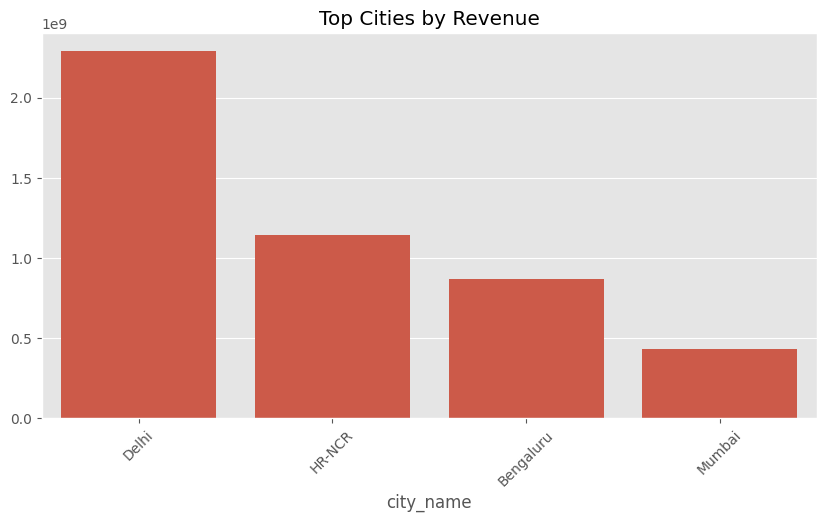

In [20]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=city_sales.head(10).index,
    y=city_sales.head(10).values
)

plt.title(
    "Top Cities by Revenue"
)

plt.xticks(rotation=45)

plt.show()

### Observation

The chart shows the cities generating the highest revenue.

# Top Product Analysis

Identifying products contributing the highest revenue.

In [21]:
top_products = (
    merged_df
    .groupby('product_name')
    ['Revenue']
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

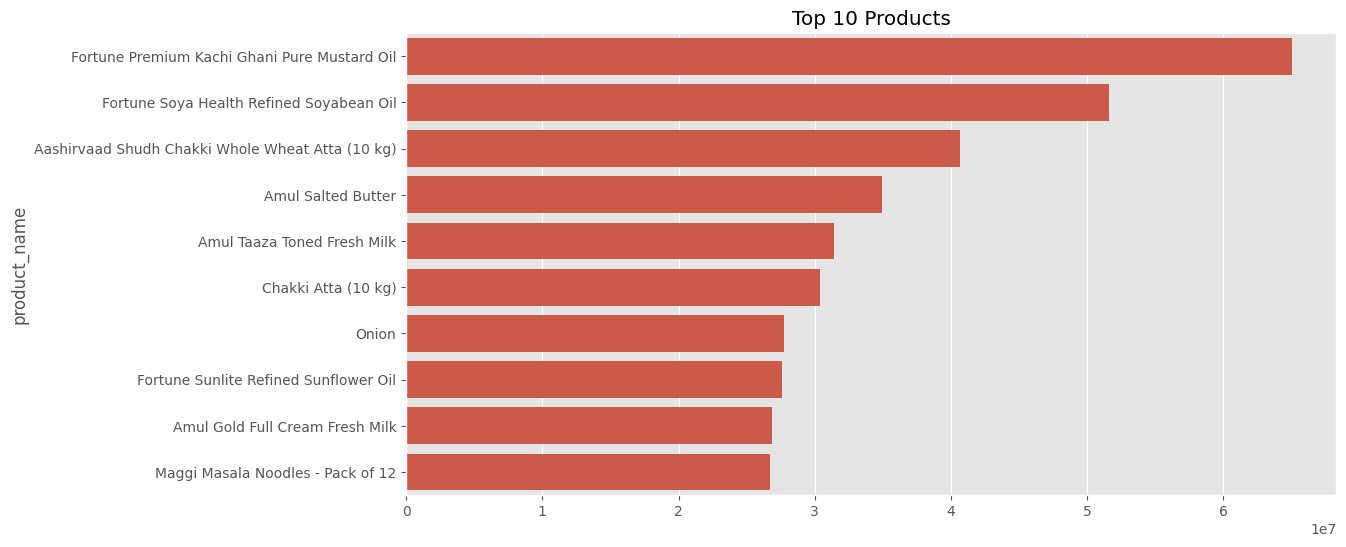

In [22]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title(
    "Top 10 Products"
)

plt.show()

### Observation

The products shown above are the highest revenue generating products.

# Category Revenue Share

Understanding revenue contribution across product categories.

In [23]:
category_sales = (
    merged_df
    .groupby('l1_category')
    ['Revenue']
    .sum()
    .sort_values(
        ascending=False
    )
)

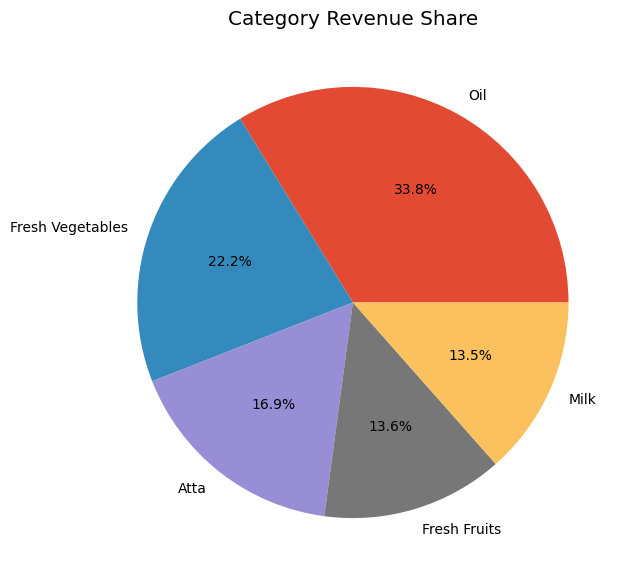

In [24]:
category_sales.head(5).plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title(
    "Category Revenue Share"
)

plt.ylabel("")

plt.show()

# Business Insights

Based on the analysis:

- Identify highest revenue city
- Identify highest revenue category
- Identify top selling products
- Identify profitable business segments

In [25]:
print(
    "Highest Revenue City:",
    city_sales.idxmax()
)

print(
    "Highest Revenue Category:",
    category_sales.idxmax()
)

print(
    "Highest Revenue Product:",
    top_products.idxmax()
)

Highest Revenue City: Delhi
Highest Revenue Category: Oil
Highest Revenue Product: Fortune Premium Kachi Ghani Pure Mustard Oil


# Conclusion

This project successfully analyzed Flipkart sales and product datasets. Revenue trends, customer behavior, product performance, category contribution, and city-wise sales performance were evaluated. The findings can help improve business strategy, inventory planning, and customer engagement.